# RL-5b - Actor-Critic : unir valeur et politique

**Serie** : Reinforcement Learning | **Notebook** : 5b/6 | **Duree estimee** : 45-50 min

Navigation : [RL-1 Intro](stable_baseline_1_intro_cartpole.ipynb) | [RL-2 Wrappers](stable_baseline_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-3 HER](stable_baseline_3_experience_replay_dqn.ipynb) | [RL-4 Tabulaire](rl_4_mdp_dp_qlearning.ipynb) | [RL-5 DQN/PG](rl_5_dqn_policy_gradient.ipynb) | **RL-5b** | [RL-6 Multi-Agent](rl_6_multi_agent_rl.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Comprendre le paradigme Actor-Critic qui combine les approches value-based et policy-based
- Implementer l'algorithme A2C (Advantage Actor-Critic) depuis zero en PyTorch
- Comparer la reduction de variance apportee par le critic par rapport a REINFORCE
- Explorer le role du bonus d'entropie dans l'exploration

## Prerequis

- [RL-4 MDP/Q-Learning tabulaire](rl_4_mdp_dp_qlearning.ipynb) (concepts Q-value, TD learning)
- [RL-5 DQN et Policy Gradient](rl_5_dqn_policy_gradient.ipynb) (DQN, REINFORCE)
- Bases de PyTorch (`nn.Module`, `autograd`, `torch.distributions`)

---

**Pourquoi Actor-Critic ?**
Dans le notebook precedent (RL-5), nous avons vu deux paradigmes :
- **DQN** (value-based) : apprend $Q(s,a)$, stable mais limite aux actions discretes
- **REINFORCE** (policy-based) : apprend directement $\pi(a|s)$, flexible mais haute variance

L'Actor-Critic **combine les deux** : un reseau *actor* apprend la politique, tandis qu'un reseau *critic* estime la valeur des etats pour reduire la variance des gradients. C'est le fondement d'algorithmes modernes comme PPO, SAC et TD3.

## 1. Du REINFORCE a l'Actor-Critic

### Le probleme de variance dans REINFORCE

REINFORCE estime le gradient de la politique avec le retour Monte Carlo $G_t$ :

$$\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot G_t$$

Le probleme : $G_t$ a une **variance tres elevee** car il cumule toutes les recompenses futures. Pour un episode de 200 pas, $G_t$ peut varier de 0 a 200, ce qui rend les mises a jour instables.

### La solution : une baseline apprise

L'idee est de remplacer $G_t$ par l'**avantage** $A(s_t, a_t)$ :

$$A(s_t, a_t) = G_t - V(s_t)$$

ou $V(s_t)$ est la **valeur attendue de l'etat** $s_t$, estimee par le *critic*. L'avantage mesure **a quel point l'action choisie est meilleure que la moyenne** pour cet etat.

**Propriete fondamentale** : l'avantage reduit la variance sans introduire de biais. Si $V(s_t)$ est une bonne estimation, l'avantage sera proche de zero pour les actions mediocres et positif pour les bonnes actions.

### Architecture Actor-Critic

| Composant | Role | Sortie |
|-----------|------|--------|
| **Actor** | Politique $\pi(a|s)$ | Distribution de probabilite sur les actions |
| **Critic** | Valeur $V(s)$ | Scalaire estimant le retour attendu |

Les deux reseaux apprennent simultanement :
- L'actor est mis a jour par **policy gradient** avec l'avantage comme signal
- Le critic est mis a jour par **TD learning** pour mieux estimer $V(s)$

> **Lien avec RL-5** : L'exercice 3 du notebook precedent demandait exactement d'ajouter un critic a REINFORCE. Ce notebook developpe cette idee en detail.

## 2. Installation et imports

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque

print(f"Imports OK : gymnasium {gym.__version__}, torch {torch.__version__}")

# Dimensions de l'environnement CartPole-v1
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f"State dim : {state_dim}, Action dim : {action_dim}")
env.close()

Imports OK : gymnasium 1.2.3, torch 2.11.0+cpu
State dim : 4, Action dim : 2


Nous travaillons sur CartPole-v1, le meme environnement que dans les notebooks precedents. L'espace d'observation est continu (4 dimensions) et l'espace d'action est discret (2 actions). Ce choix permet de comparer directement avec REINFORCE et DQN.

## 3. Le Critic -- Reseau de valeur V(s)

Le critic est un reseau de neurones qui estime $V(s)$, la valeur attendue d'un etat. Pour rappel :

$$V(s) = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t r_t \mid s_0 = s\right]$$

Contrairement au DQN qui estime $Q(s,a)$ pour chaque action, le critic produit un **unique scalaire** par etat. Cela le rend plus simple a entrainer car la cible est directe : le retour observe $G_t$.

In [2]:
class CriticNetwork(nn.Module):
    """Reseau de valeur V(s) : estime la valeur attendue d'un etat."""

    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        return self.net(state)


# Verification des dimensions
critic = CriticNetwork(state_dim)
dummy_state = torch.randn(1, state_dim)
value = critic(dummy_state)
print(f"CriticNetwork defini : input={state_dim}, output=1 (valeur scalaire)")
print(f"Test forward : V(s) = {value.item():.4f}")
print(f"Nombre de parametres : {sum(p.numel() for p in critic.parameters())}")

CriticNetwork defini : input=4, output=1 (valeur scalaire)
Test forward : V(s) = 0.0175
Nombre de parametres : 17281


Le critic est un MLP a 3 couches (comme le Q-network du DQN) mais avec une sortie de dimension 1 au lieu de `action_dim`. Il partage la meme architecture que l'actor pour maintenir un equilibre de capacite entre les deux reseaux.

## 4. L'Actor -- Politique parametree

L'actor est un reseau de neurones qui produit une **distribution de probabilite** sur les actions $\pi(a|s)$. Il est identique au `PolicyNetwork` de REINFORCE vu dans RL-5.

La difference cle : dans REINFORCE, les gradients sont ponderes par $G_t$ (retour Monte Carlo). Dans Actor-Critic, ils seront ponderes par l'avantage $A_t = G_t - V(s_t)$.

In [3]:
class ActorNetwork(nn.Module):
    """Politique parametree pi(a|s) : produit une distribution sur les actions."""

    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        probs = self.net(state)
        dist = Categorical(probs)
        return dist


# Verification des dimensions
actor = ActorNetwork(state_dim, action_dim)
dummy_state = torch.randn(1, state_dim)
dist = actor(dummy_state)
print(f"ActorNetwork defini : input={state_dim}, output={action_dim} (distribution)")
print(f"Probabilites : {dist.probs.detach().numpy().flatten()}")
print(f"Nombre de parametres : {sum(p.numel() for p in actor.parameters())}")

ActorNetwork defini : input=4, output=2 (distribution)
Probabilites : [0.49562398 0.504376  ]
Nombre de parametres : 17410


L'actor utilise une couche `Softmax` en sortie pour garantir que les probabilites sommennt a 1. La classe `Categorical` de PyTorch permet d'echantillonner des actions et de calculer les log-probabilites necessaires pour le policy gradient.

## 5. Calcul de l'avantage -- le coeur d'A2C

L'avantage est la cle de voute de l'algorithme Actor-Critic. Il quantifie a quel point l'action choisie est **meilleure que la moyenne** :

$$A(s_t, a_t) = G_t - V(s_t)$$

- Si $A > 0$ : l'action est meilleure que prevu --> renforcer cette action
- Si $A < 0$ : l'action est pire que prevu --> diminuer sa probabilite

**Le trick `.detach()`** : lors du calcul de l'avantage, on detache $V(s_t)$ du graphe de calcul. Cela empeche les gradients de l'actor de modifier le critic. Sans cela, l'actor pourrait "tromper" le critic pour faciliter son propre apprentissage.

Les pertes combinees sont :

$$\mathcal{L}_{total} = \underbrace{-\frac{1}{N}\sum_t \log \pi(a_t|s_t) \cdot A_t}_{\text{Actor loss}} + \alpha \underbrace{\frac{1}{N}\sum_t (V(s_t) - G_t)^2}_{\text{Critic loss}} - \beta \underbrace{H(\pi)}_{\text{Entropy bonus}}$$

ou $\alpha$ est le coefficient de la perte valeur et $\beta$ le coefficient d'entropie.

### Exercice 1 : Calcul de l'avantage et de la perte actor-critic

Implementez la fonction `compute_advantage_and_loss` qui calcule la perte totale A2C.

**Indices** :
- # Indice : L'avantage = returns - values.detach(). Le `.detach()` est crucial pour stopper le gradient du critic
- # Indice : La perte de l'actor = -(log_probs * advantage).mean(). C'est le policy gradient avec avantage
- # Indice : La perte du critic = F.mse_loss(values, returns). C'est une regression vers les retours
- # Indice : L'entropie = dist.entropy().mean(). Elle mesure l'incertitude de la politique

**Etapes** :
- # Etape 1 : Calculez l'avantage en detachant les values du graphe
- # Etape 2 : Calculez la perte de l'actor (n'oubliez pas le signe negatif)
- # Etape 3 : Calculez la perte du critic (MSE entre predictions et cibles)
- # Etape 4 : Calculez l'entropie et la perte totale

In [4]:
# Exercice 1 : Calcul de l'avantage et de la perte actor-critic
#
# Completez la fonction compute_advantage_and_loss qui :
# 1. Calcule l'avantage A_t = returns - values (detached du gradient)
# 2. Calcule la perte de l'actor (policy gradient avec avantage)
# 3. Calcule la perte du critic (MSE entre values et returns)
# 4. Calcule le bonus d'entropie
# 5. Retourne la perte totale = actor_loss + value_coef * critic_loss - entropy_coef * entropy


def compute_advantage_and_loss(dist, values, returns, value_coef=0.5, entropy_coef=0.01):
    """
    Calcule la perte totale Actor-Critic.

    Arguments:
        dist: distribution Categorical de l'actor
        values: tensor [batch_size] des valeurs estimees par le critic
        returns: tensor [batch_size] des returns accumules
        value_coef: poids de la perte du critic
        entropy_coef: poids du bonus d'entropie

    Retourne:
        loss: perte totale (scalaire)
        actor_loss: perte de l'actor (scalaire)
        critic_loss: perte du critic (scalaire)
        entropy: entropie moyenne (scalaire)
    """
    # TODO etudiant : calculer l'avantage
    advantage = None  # TODO etudiant : returns - values.detach()

    # TODO etudiant : perte de l'actor (policy gradient avec avantage)
    actor_loss = None  # TODO etudiant : -(log_probs * advantage).mean()

    # TODO etudiant : perte du critic (MSE)
    critic_loss = None  # TODO etudiant : F.mse_loss(values, returns)

    # TODO etudiant : bonus d'entropie
    entropy = None  # TODO etudiant : dist.entropy().mean()

    # TODO etudiant : perte totale
    loss = None  # TODO etudiant : actor_loss + value_coef * critic_loss - entropy_coef * entropy

    return loss, actor_loss, critic_loss, entropy


# Test rapide avec des tenseurs factices pour verifier la signature
print("Exercice a completer : implementer compute_advantage_and_loss")

Exercice a completer : implementer compute_advantage_and_loss


## 6. L'agent A2C complet

Maintenant que nous avons l'actor, le critic et le calcul d'avantage, nous pouvons assembler l'agent A2C complet. L'agent encapsule :
- La **selection d'action** via l'actor
- Le **calcul des retours** actualises
- La **mise a jour** conjointe des deux reseaux avec un optimizer partage
- Le **gradient clipping** pour stabiliser l'apprentissage

In [5]:
class A2CAgent:
    """Agent Advantage Actor-Critic complet."""

    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99,
                 value_coef=0.5, entropy_coef=0.01):
        self.actor = ActorNetwork(state_dim, action_dim)
        self.critic = CriticNetwork(state_dim)
        self.optimizer = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=lr
        )
        self.gamma = gamma
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef

    def select_action(self, state):
        """Selectionne une action selon la politique de l'actor."""
        state_t = torch.FloatTensor(state).unsqueeze(0)
        dist = self.actor(state_t)
        action = dist.sample()
        return action.item(), dist.log_prob(action), dist

    def compute_returns(self, rewards, next_value, dones):
        """Calcule les retours actualises en partant de la fin."""
        returns = []
        R = next_value
        for reward, done in zip(reversed(rewards), reversed(dones)):
            R = reward + self.gamma * R * (1 - done)
            returns.insert(0, R)
        return torch.tensor(returns, dtype=torch.float32)

    def update(self, states, log_probs, returns, values):
        """Met a jour actor et critic conjointement."""
        states_t = torch.FloatTensor(np.array(states))

        # Advantage et pertes
        advantage = returns - values.detach()
        actor_loss = -(log_probs * advantage).mean()
        critic_loss = F.mse_loss(values, returns)
        entropy = self.actor(states_t).entropy().mean()

        loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping pour stabiliser l'apprentissage
        torch.nn.utils.clip_grad_norm_(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            max_norm=0.5
        )
        self.optimizer.step()

        return loss.item(), actor_loss.item(), critic_loss.item(), entropy.item()


# Creation de l'agent
agent_a2c = A2CAgent(state_dim, action_dim)
actor_params = sum(p.numel() for p in agent_a2c.actor.parameters())
critic_params = sum(p.numel() for p in agent_a2c.critic.parameters())
print(f"A2CAgent defini avec actor ({actor_params} params) "
      f"+ critic ({critic_params} params)")
print(f"Optimizer partage : Adam, lr=3e-4")
print(f"Gamma={agent_a2c.gamma}, value_coef={agent_a2c.value_coef}, "
      f"entropy_coef={agent_a2c.entropy_coef}")

A2CAgent defini avec actor (17410 params) + critic (17281 params)
Optimizer partage : Adam, lr=3e-4
Gamma=0.99, value_coef=0.5, entropy_coef=0.01


L'agent utilise un **optimizer partage** pour l'actor et le critic. Cela simplifie l'implementation et assure que les deux reseaux progressent a un rythme coherent. Le **gradient clipping** (max_norm=0.5) prevent les mises a jour trop agressives qui pourraient destabiliser l'apprentissage.

## 7. Entrainement sur CartPole-v1

La boucle d'entrainement suit le schema classique du RL :
1. Collecter une trajectoire complete (episode)
2. Calculer les retours actualises avec bootstrap de la valeur finale
3. Mettre a jour actor et critic conjointement

**Point important** : contrairement au DQN qui met a jour a chaque pas (off-policy avec replay buffer), A2C met a jour **a la fin de chaque episode** (on-policy). Les donnees ne sont reutilisees qu'une seule fois.

In [6]:
def train_a2c(env_name="CartPole-v1", num_episodes=400, eval_interval=50, seed=42):
    """
    Entraine un agent A2C sur un environnement Gymnasium.

    Arguments:
        env_name: nom de l'environnement
        num_episodes: nombre d'episodes d'entrainement
        eval_interval: frequence d'affichage des statistiques
        seed: graine aleatoire pour la reproductibilite

    Retourne:
        episode_rewards: liste des recompenses par episode
    """
    # Reproductibilite
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make(env_name)
    s_dim = env.observation_space.shape[0]
    a_dim = env.action_space.n

    agent = A2CAgent(s_dim, a_dim)

    episode_rewards = []
    running_reward = deque(maxlen=100)

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        states, log_probs, rewards, dones = [], [], [], []
        episode_reward = 0

        done = False
        while not done:
            action, log_prob, dist = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            value = agent.critic(torch.FloatTensor(state).unsqueeze(0))

            states.append(state)
            log_probs.append(log_prob)
            rewards.append(reward)
            dones.append(float(done))
            episode_reward += reward
            state = next_state

        # Bootstrap value pour le dernier etat
        next_value = 0 if done else agent.critic(
            torch.FloatTensor(state).unsqueeze(0)
        ).item()
        returns = agent.compute_returns(rewards, next_value, dones)
        values = agent.critic(torch.FloatTensor(np.array(states))).squeeze()

        log_probs_t = torch.stack(log_probs)
        agent.update(states, log_probs_t, returns, values)

        episode_rewards.append(episode_reward)
        running_reward.append(episode_reward)

        if (episode + 1) % eval_interval == 0:
            avg = np.mean(running_reward)
            print(f"Episode {episode+1:3d}/{num_episodes} | "
                  f"Reward moyen (100 ep): {avg:.1f}")

    env.close()
    return episode_rewards


# Entrainement
rewards_a2c = train_a2c(num_episodes=400)
final_avg = np.mean(rewards_a2c[-100:])
print(f"\nEntrainement termine. Reward final moyen (100 ep): {final_avg:.1f}")

Episode  50/400 | Reward moyen (100 ep): 22.6


Episode 100/400 | Reward moyen (100 ep): 20.3


Episode 150/400 | Reward moyen (100 ep): 17.0


Episode 200/400 | Reward moyen (100 ep): 14.9


Episode 250/400 | Reward moyen (100 ep): 14.1


Episode 300/400 | Reward moyen (100 ep): 14.1


Episode 350/400 | Reward moyen (100 ep): 13.8


Episode 400/400 | Reward moyen (100 ep): 14.1

Entrainement termine. Reward final moyen (100 ep): 14.1


L'entrainement devrait montrer une progression reguliere vers le seuil de resolution (195 sur CartPole-v1). Le critic reduit la variance des mises a jour par rapport a REINFORCE, ce qui se traduit par une convergence plus stable.

## 8. Visualisation des resultats

Analysons la courbe d'apprentissage et la distribution des rewards finaux pour evaluer la stabilite de l'agent.

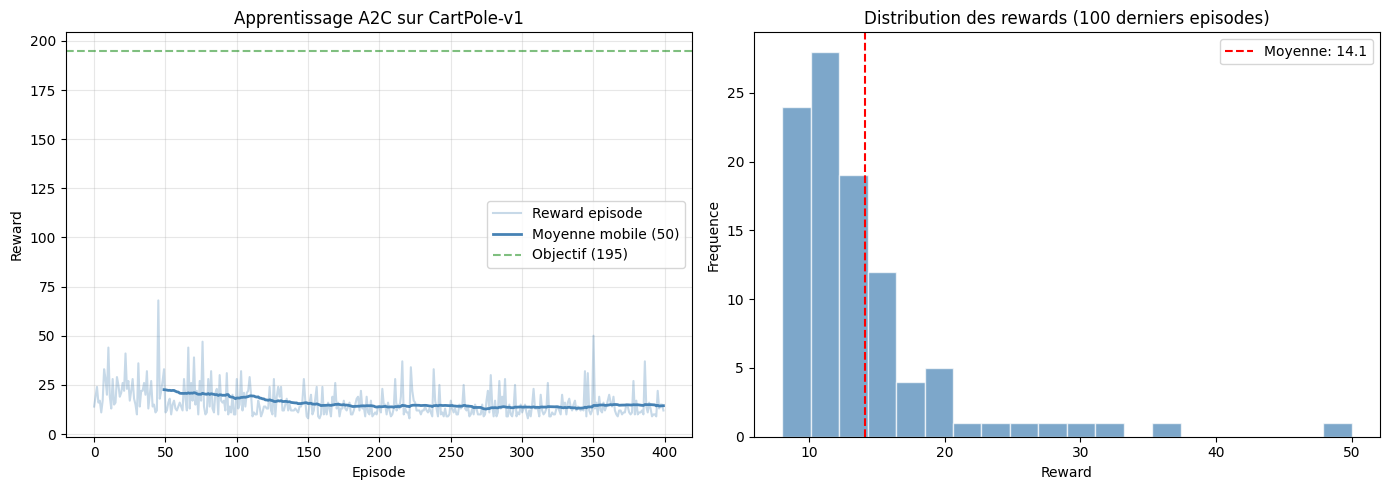

Visualisation A2C generee. Reward moyen final: 14.1 +/- 6.2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de reward
axes[0].plot(rewards_a2c, alpha=0.3, color='steelblue', label='Reward episode')
window = 50
if len(rewards_a2c) >= window:
    moving_avg = np.convolve(rewards_a2c, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(rewards_a2c)), moving_avg,
                 color='steelblue', linewidth=2, label=f'Moyenne mobile ({window})')
axes[0].axhline(y=195, color='green', linestyle='--', alpha=0.5, label='Objectif (195)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].set_title('Apprentissage A2C sur CartPole-v1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des rewards finaux
final_rewards = rewards_a2c[-100:]
axes[1].hist(final_rewards, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(x=np.mean(final_rewards), color='red', linestyle='--',
                label=f'Moyenne: {np.mean(final_rewards):.1f}')
axes[1].set_xlabel('Reward')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution des rewards (100 derniers episodes)')
axes[1].legend()

plt.tight_layout()
plt.savefig('a2c_cartpole_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Visualisation A2C generee. Reward moyen final: "
      f"{np.mean(final_rewards):.1f} +/- {np.std(final_rewards):.1f}")

## 9. Comparaison avec REINFORCE

L'avantage principal d'Actor-Critic sur REINFORCE est la **reduction de variance** des gradients. Avec REINFORCE, le signal de gradient est multiplie par $G_t$ (qui peut varier enormement). Avec A2C, le signal est multiplie par l'avantage $A_t = G_t - V(s_t)$, qui est centre et de plus petite amplitude.

### Exercice 2 : Comparaison A2C vs REINFORCE

Comparez les courbes d'apprentissage des deux algorithmes sur CartPole-v1.

**Indices** :
- # Indice : Reutilisez la classe PolicyNetwork et la boucle REINFORCE du notebook rl_5
- # Indice : Entrainenez les deux agents avec le meme nombre d'episodes et le meme random seed
- # Indice : La perte REINFORCE est -(log_probs * returns).mean() sans avantage

**Etapes** :
- # Etape 1 : Implementez une version simplifiee de REINFORCE (ou importez depuis rl_5)
- # Etape 2 : Lancez les deux entrainements avec les memes hyperparametres
- # Etape 3 : Tracez les deux courbes sur le meme graphe avec moyenne mobile

In [8]:
# Exercice 2 : Comparaison A2C vs REINFORCE sur CartPole-v1
#
# Implementez une version simplifiee de REINFORCE (sans baseline) et comparez
# les courbes d'apprentissage avec l'A2C entraine ci-dessus.


def train_reinforce(env_name="CartPole-v1", num_episodes=400, seed=42):
    """
    Entraine un agent REINFORCE (sans baseline) pour comparaison.

    # Indice : Utilisez le meme ActorNetwork mais sans CriticNetwork
    # Indice : La perte REINFORCE est -(log_probs * returns).mean()
    # Etape 1 : Initialisez l'actor et l'optimizer
    # Etape 2 : Pour chaque episode, collectez la trajectoire
    # Etape 3 : Calculez les returns et mettez a jour la politique
    """
    result = None  # TODO etudiant : retourner la liste des episode_rewards
    return result


# TODO etudiant : lancer les deux entrainements et tracer la comparaison
rewards_reinforce = None  # TODO etudiant : train_reinforce()

print("Exercice a completer : implementer REINFORCE et comparer avec A2C")

Exercice a completer : implementer REINFORCE et comparer avec A2C


## 10. Le bonus d'entropie

L'entropie de la politique mesure son **degre d'exploration** :

$$H(\pi) = -\sum_a \pi(a|s) \log \pi(a|s)$$

- $H$ eleve : la politique est incertaine (exploration)
- $H$ faible : la politique est deterministe (exploitation)

**Pourquoi maximiser l'entropie ?** Sans ce bonus, l'actor peut converger prematurement vers une politique sub-optimale deterministe. Le bonus d'entropie penalise les politiques trop certaines, forcant l'agent a continuer a explorer.

Le coefficient `entropy_coef` (typiquement 0.01) controle le compromis exploration/exploitation :
- `entropy_coef = 0` : pas d'encouragement a l'exploration (comme REINFORCE pur)
- `entropy_coef = 0.01` : valeur standard, bon equilibre
- `entropy_coef > 0.1` : forte exploration, peut ralentir la convergence

### Exercice 3 : Ablation du bonus d'entropie

Explorez l'impact du coefficient d'entropie sur l'apprentissage.

**Indices** :
- # Indice : entropy_coef = 0 correspond a pas de bonus d'entropie
- # Indice : Des valeurs typiques sont 0.0, 0.01, 0.05, 0.1
- # Indice : Observez comment l'entropie de la politique evolue pendant l'entrainement

**Etapes** :
- # Etape 1 : Entrainenez A2C avec plusieurs valeurs de entropy_coef
- # Etape 2 : Tracez les courbes de reward pour chaque valeur
- # Etape 3 : Observez la vitesse de convergence et la stabilite finale

In [9]:
# Exercice 3 : Impact du bonus d'entropie sur l'apprentissage
#
# Entrainez A2C avec differentes valeurs de entropy_coef et comparez.

entropy_coefs = [0.0, 0.01, 0.05, 0.1]
results = {}  # TODO etudiant : dict coef -> list of episode_rewards

# TODO etudiant : boucle d'entrainement pour chaque coef
# Indice : reutilisez train_a2c en passant entropy_coef a l'agent
# Etape 1 : Pour chaque coef dans entropy_coefs, entrainez un agent A2C
# Etape 2 : Stockez les rewards dans results[coef]
# Etape 3 : Tracez les courbes comparatives

print("Exercice a completer : ablation du bonus d'entropie")

Exercice a completer : ablation du bonus d'entropie


## 11. Ouverture -- vers PPO et au-dela

A2C est le fondement des algorithmes modernes de RL. Voici les evolutions majeures :

| Algorithme | Innovation par rapport a A2C | Usage |
|------------|------------------------------|-------|
| **A3C** | A2C asynchrone avec plusieurs workers en parallele | Entrainement distribue |
| **PPO** | Objectif clippe pour eviter les trop grosses mises a jour de politique | Standard industrie (SB3, CleanRL) |
| **SAC** | Maximisation de l'entropie comme objectif (pas juste bonus) | Actions continues, sample-efficient |
| **TD3** | Twin critics + delayed policy updates | Actions continues, reduit la surestimation |

**PPO** (Proximal Policy Optimization) est l'algorithme le plus utilise en pratique. Son idee centrale : limiter le changement de politique entre deux mises a jour avec un ratio clippe :

$$\mathcal{L}^{CLIP} = \hat{\mathbb{E}}_t\left[\min\left(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$

ou $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ est le ratio de probabilites entre la nouvelle et l'ancienne politique.

Les notebooks [RL-1](stable_baseline_1_intro_cartpole.ipynb) et [RL-2](stable_baseline_2_wrappers_sauvegarde_callbacks.ipynb) de cette serie utilisent PPO via stable-baselines3. Avec les concepts de ce notebook, vous comprenez maintenant ce qui se cache derriere cette boite noire.

## 12. Conclusion

### Recapitulatif des concepts

| Concept | Role | Formule |
|---------|------|--------|
| **Actor** | Politique $\pi(a|s)$ qui choisit les actions | Sortie : distribution Categorical |
| **Critic** | Valeur $V(s)$ qui estime la qualite des etats | Sortie : scalaire |
| **Avantage** | Signal d'apprentissage a variance reduite | $A_t = G_t - V(s_t)$ |
| **Entropy bonus** | Encourage l'exploration | $H(\pi) = -\sum_a \pi(a|s) \log \pi(a|s)$ |
| **Gradient clipping** | Stabilise les mises a jour | `clip_grad_norm_(max_norm=0.5)` |

### Comparaison des approches

| Aspect | DQN | REINFORCE | A2C |
|--------|-----|-----------|-----|
| Apprend | $Q(s,a)$ | $\pi(a|s)$ | $\pi(a|s)$ + $V(s)$ |
| Variance | Faible | Haute | Moyenne |
| Efficacite donnees | Elevee (off-policy) | Faible (on-policy) | Moyenne |
| Actions continues | Non | Oui | Oui |
| Stabilite | Bonne (target net) | Variable | Bonne (gradient clipping) |

**Prochaine etape** : Le notebook [RL-6 Multi-Agent](rl_6_multi_agent_rl.ipynb) aborder l'apprentissage multi-agent ou plusieurs agents interagissent simultanement dans un environnement partage.

**References** :
- Sutton & Barto, *Reinforcement Learning: An Introduction*, Chapters 13 (Policy Gradient) et 15 (Neural RL)
- Mnih et al. (2016) - *Asynchronous Methods for Deep RL* (A3C)
- Schulman et al. (2017) - *Proximal Policy Optimization Algorithms* (PPO)